# Car Price Predictions using Machine Learning

## Import Libraries

In [1]:
# Data Manipulation 
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

#Evaluation Metrics
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [2]:
# Load dataset

df = pd.read_csv("car data.csv")

#Display 1st 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Dataset Overview

In [3]:
# Shape of dataset
print("Rows and Columns:",df.shape)

Rows and Columns: (301, 9)


In [4]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
#Statistical Summary
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Missing values Check

In [6]:
# Check missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## Duplicate Values Check

In [7]:
# check duplicate values
df.duplicated().sum()

2

In [8]:
# Remove duplicates

df.drop_duplicates(inplace=True)

print("New Shape :", df.shape)

New Shape : (299, 9)


## Feature Engineering

### Create Car Age Feature

In [9]:
# Creating car age feature

current_year = df['Year'].max()

df['Car_Age'] = current_year - df['Year']

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4


## Exploratory Data Analysis (EDA)
### Selling Price Distribution

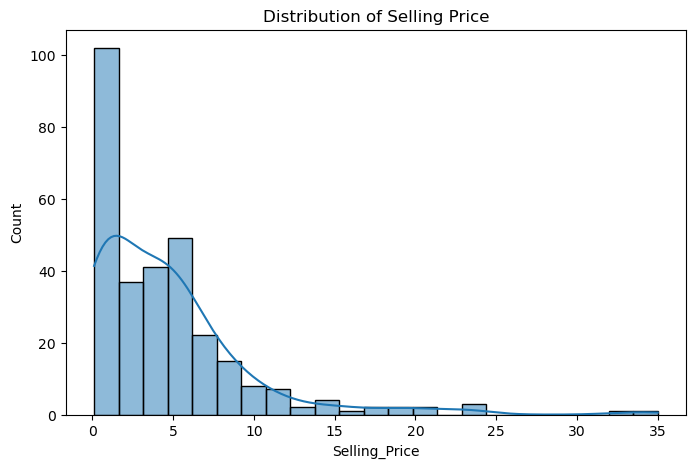

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'],
             kde=True)

plt.title("Distribution of Selling Price")
plt.show()

### Car Age vs Selling Price

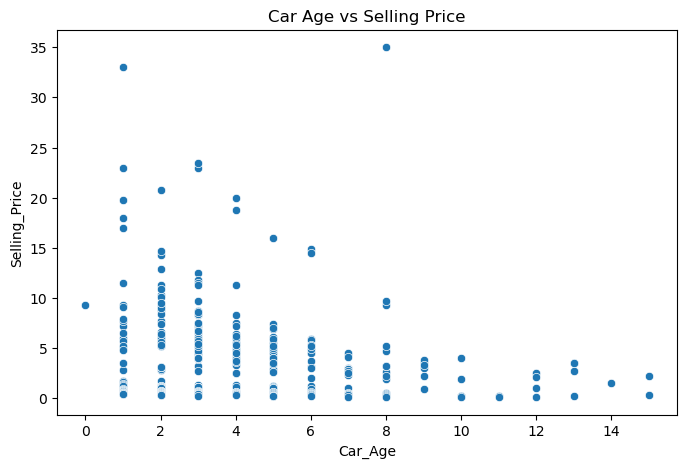

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Car_Age',
    y='Selling_Price',
    data=df
)

plt.title("Car Age vs Selling Price")
plt.show()

### Present Price vs Selling Price

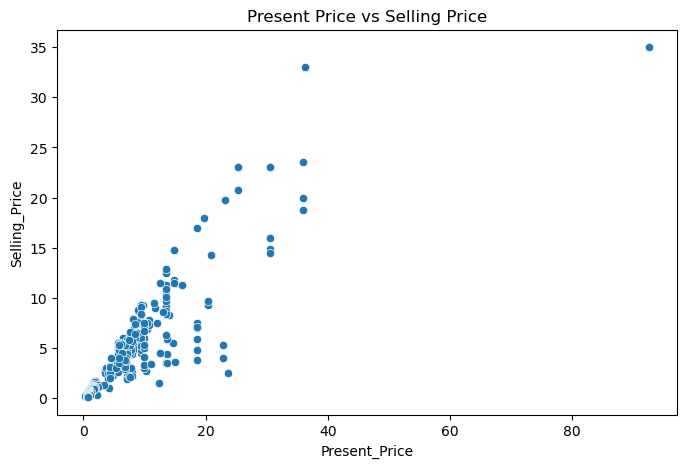

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=df
)

plt.title("Present Price vs Selling Price")
plt.show()

### Fuel Type Distribution

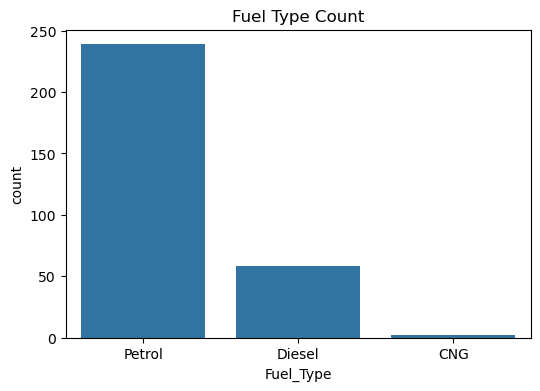

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Fuel_Type',
    data=df
)

plt.title("Fuel Type Count")
plt.show()

### Transmission Distribution

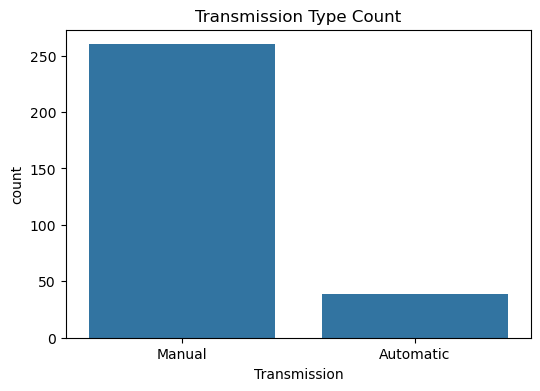

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Transmission',
    data=df
)

plt.title("Transmission Type Count")
plt.show()

# Fuel Type vs Selling Price

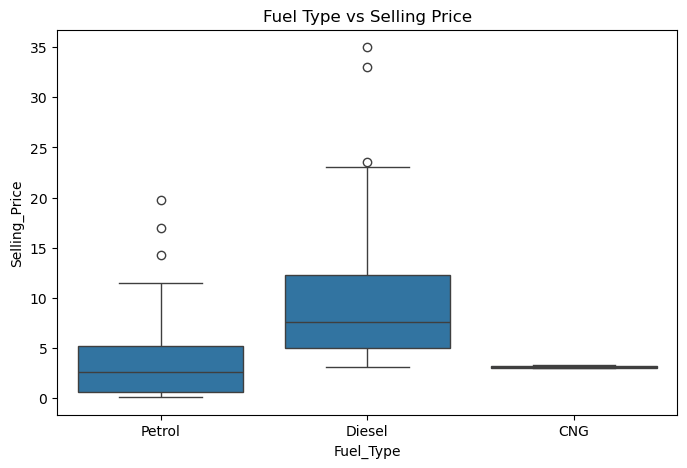

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Fuel_Type',
    y='Selling_Price',
    data=df
)

plt.title("Fuel Type vs Selling Price")
plt.show()

# Transmission vs Selling Price

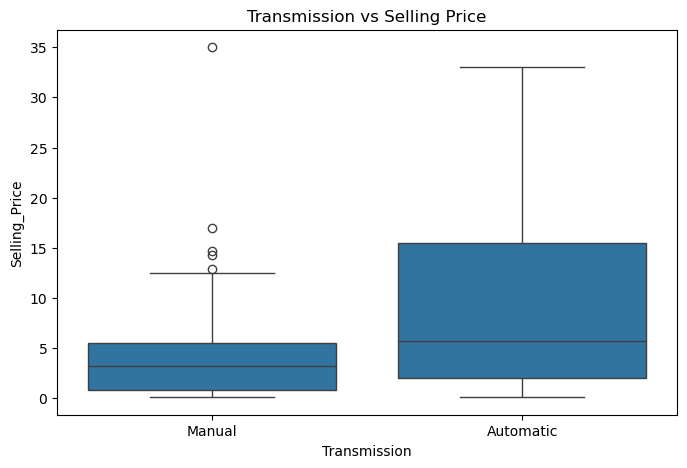

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Transmission',
    y='Selling_Price',
    data=df
)

plt.title("Transmission vs Selling Price")
plt.show()

### Owner vs Selling Price

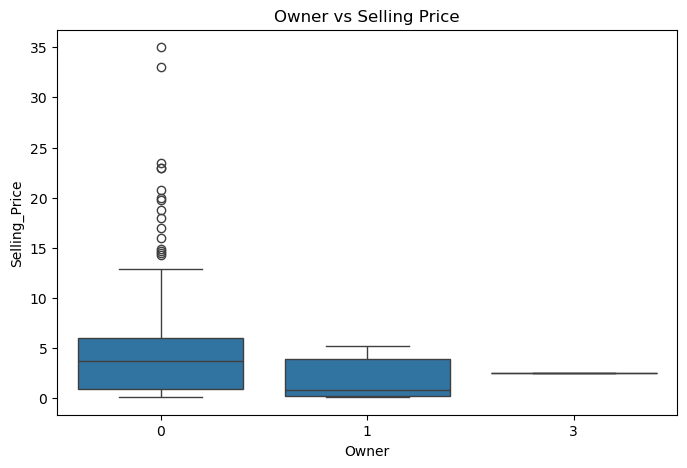

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Owner',
    y='Selling_Price',
    data=df
)

plt.title("Owner vs Selling Price")
plt.show()

### Driven Kms vs Selling Price

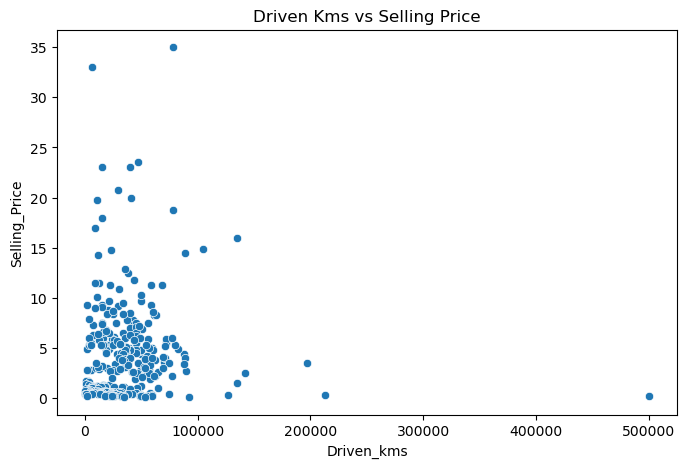

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Driven_kms',
    y='Selling_Price',
    data=df
)

plt.title("Driven Kms vs Selling Price")
plt.show()

## Encoding Categorical Variables

In [19]:
# Label Encoding

le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

df['Selling_type'] = le.fit_transform(df['Selling_type'])

df['Transmission'] = le.fit_transform(df['Transmission'])

## Correlation Heatmap

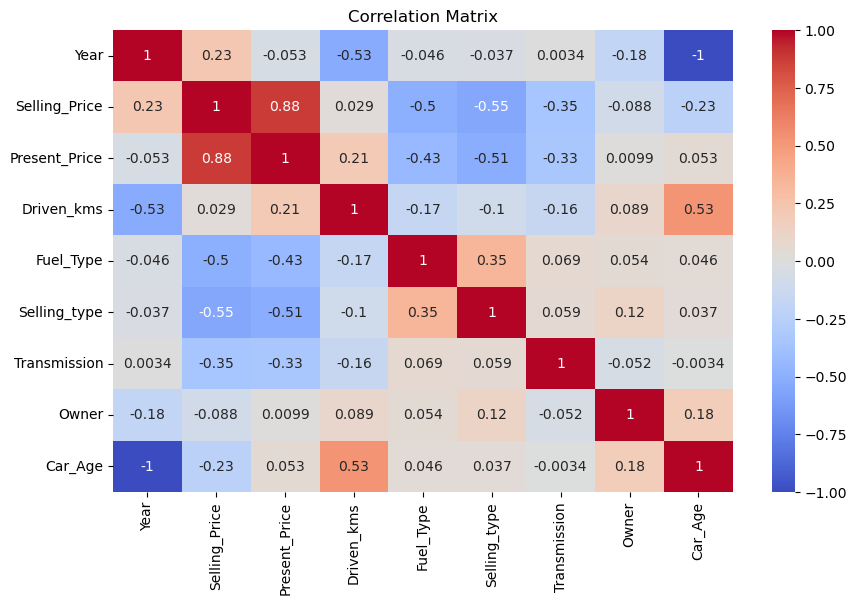

In [20]:
df = df.drop('Car_Name', axis=1)
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

## Feature Selection

In [21]:
# Input Features

X = df.drop(
    ['Selling_Price','Year'],
    axis=1
)

# Target Variable

y = df['Selling_Price']

## Train Test Split


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression

In [23]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Evaluation

In [24]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test,y_pred_lr))

print("RMSE :",
      np.sqrt(mean_squared_error(y_test,y_pred_lr)))

print("R2 Score :",
      r2_score(y_test,y_pred_lr))

Linear Regression
MAE : 1.540811954969353
RMSE : 2.5836880811143303
R2 Score : 0.7409934356413543


## Random Forest Regression

In [25]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

### Evaluation

In [26]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test,y_pred_rf))

print("RMSE :",
      np.sqrt(mean_squared_error(y_test,y_pred_rf)))

print("R2 Score :",
      r2_score(y_test,y_pred_rf))

Random Forest
MAE : 1.4026667996875635
RMSE : 3.304471490113645
R2 Score : 0.5763232556739033


In [27]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.9518522050844431
0.5763232556739033


## Ridge Regression 

In [28]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

In [29]:
print("Ridge Regression")

print("MAE :",
      mean_absolute_error(y_test, y_pred_ridge))

print("RMSE :",
      np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

print("R2 Score :",
      r2_score(y_test, y_pred_ridge))

Ridge Regression
MAE : 1.5331230556714608
RMSE : 2.566763082287425
R2 Score : 0.7443756764747809


## Model Comparison

In [30]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Random Forest"
    ],

    "R2 Score":[

        r2_score(y_test,y_pred_lr),

        r2_score(y_test,y_pred_ridge),

        r2_score(y_test,y_pred_rf)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.740993
1,Ridge Regression,0.744376
2,Random Forest,0.576323


In [31]:
results = pd.DataFrame({
    "Model":["Linear Regression","Ridge Regression","Random Forest"],
    "MAE":[
        mean_absolute_error(y_test,y_pred_lr),
        mean_absolute_error(y_test,y_pred_ridge),
        mean_absolute_error(y_test,y_pred_rf)
    ],
    "R2 Score":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_ridge),
        r2_score(y_test,y_pred_rf)
    ]
})

results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,R2 Score
1,Ridge Regression,1.533123,0.744376
0,Linear Regression,1.540812,0.740993
2,Random Forest,1.402667,0.576323


## Actual vs Predicted

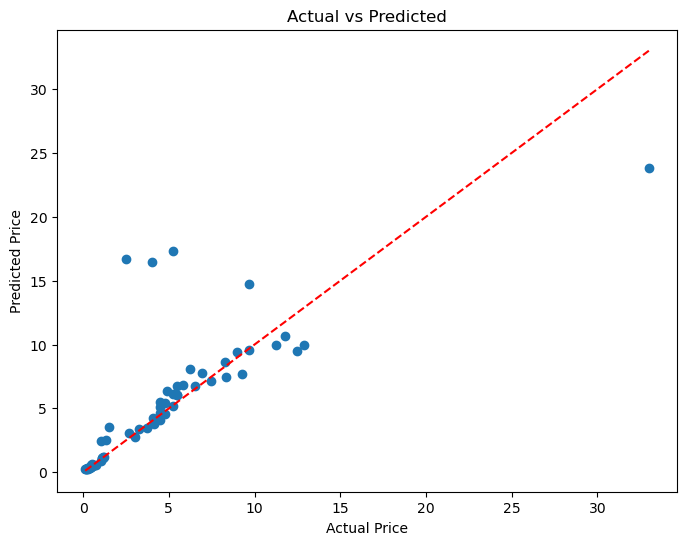

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

## Feature Importance

In [33]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Present_Price,9.253200e-01
6,Car_Age,5.694601e-02
1,Driven_kms,1.125625e-02
4,Transmission,3.898400e-03
3,Selling_type,1.927496e-03
2,Fuel_Type,6.513296e-04
5,Owner,5.500595e-07


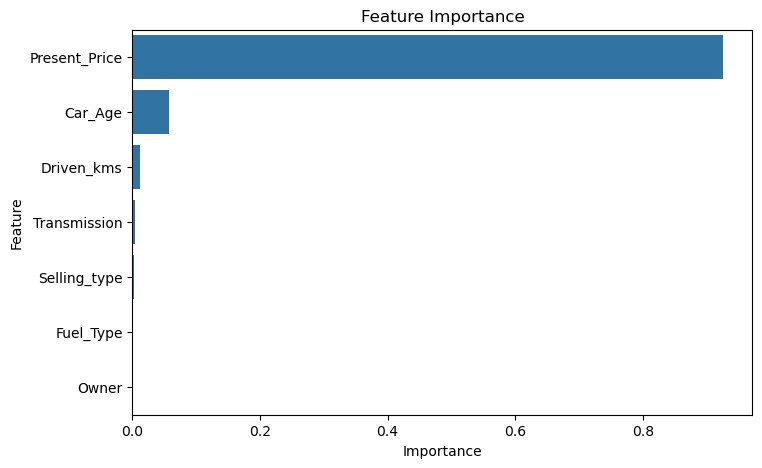

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

## Conclusion
1. Present Price is the most important feature.
2. Car Age negatively affects Selling Price.
3. Random Forest achieved the best performance.
4. The model can estimate the resale value of used cars.

## Future Improvements

1. More data can improve performance.
2. Hyperparameter tuning can be applied.
3. Advanced models such as XGBoost can be tested.
4. A web application can be built using Streamlit.

### Ridge Regression was selected as the final model because it achieved the highest test R² score (0.744) and showed better generalization performance than Random Forest Regression.